In [ ]:
# dosya formatları
# api ile veri alma
# json, jsonc, yaml, toml, ini, csv, xml , env

# api -> json veri çekme, json veriyi parse etme,
# kullanıcı bilgileri, sistem ayarları

In [ ]:
# xml formatı
print("""
      
      
      
      """)

In [4]:
with open("./dataformats/data.csv", "r") as f:
    data = f.read()
    x = data.split("\n")
    for i in x:
        a = i.split(";")
        print(a)
    # print(data)


['ömer nuri', '123', 'nilüfer']
['enes', '124', '"osmangazi', 'bursa\\""']


In [12]:
import pandas as pd

data = pd.read_csv("./dataformats/data.csv", sep=";", header=0, encoding="utf-8")
print(data)

        isim   id                yer
0  ömer nuri  123            nilüfer
1       enes  124  osmangazi;"bursa"


In [15]:
%pip install lxml
data_xml = pd.read_xml("./dataformats/data.xml")
print(data_xml)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 62.0 kB/s  0:00:49 eta 0:00:05m
Note: you may need to restart the kernel to use updated packages.
          Ad   Id              Yer
0  Ömer Nuri  123          Nilüfer
1       Enes  124  Osmangazi;Bursa


In [17]:
with open("dataformats/data.env") as f:
    data = f.read()
    lines = data.splitlines()
    for i in lines:
        x = i.split("=")
        print(x)
    print(data)

['kullanici', 'ömer nuri']
['numara', '123']
['yer', 'nilüfer bursa']
kullanici=ömer nuri
numara=123
yer=nilüfer bursa



In [20]:
import configparser


config = configparser.ConfigParser()
config.read("dataformats/data.ini")

print(config["Kullanici_1"]["Ad"])


Ömer Nuri


In [21]:
data_toml = pd.read_table("dataformats/data.toml", sep="\n", header=None)
print(data_toml)

ValueError: Specified \n as separator or delimiter. This forces the python engine which does not accept a line terminator. Hence it is not allowed to use the line terminator as separator.

In [22]:
import pyaml 
with open("dataformats/data.yaml") as f:
    data = pyaml.safe_load(f)
    print(data)

AttributeError: module 'pandas' has no attribute 'read_yaml'

In [23]:
#json 
import json
with open("dataformats/data.json") as f:
    data = json.load(f)
    print(data)

{'data': {'Kullanici': [{'ad': 'Ömer Nuri', 'id': 123, 'yer': 'Nilüfer'}, {'ad': 'Enes', 'id': 124, 'yer': 'Osmangazi;Bursa'}]}}


In [25]:
x = {
    "data": {
        "Kullanici": [
            {
                "ad": "Ömer Nuri",
                "id": 123,
                "yer": "Nilüfer",
                "dersler" : ["matematik", "fizik", "kimya"]
            },
            {
                "ad": "Enes",
                "id": 124,
                "yer": "Osmangazi;Bursa"
            }
        ]
    }
}

x["data"]["Kullanici"][0]["dersler"][1]

'fizik'

In [30]:
# APPLICATION INTERFACE (API)
# uygulama arayüzüx
%pip install requests
import requests

api_url = "https://api.open-meteo.com/v1/forecast?latitude=39&longitude=29&current=temperature_2m,wind_speed_10m&hourly=temperature_2m,relative_humidity_2m,wind_speed_10m"

response = requests.get(api_url)
data_weather = response.json()
print(data_weather)


Note: you may need to restart the kernel to use updated packages.
{'latitude': 39.0, 'longitude': 29.0, 'generationtime_ms': 0.22876262664794922, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 1062.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C', 'wind_speed_10m': 'km/h'}, 'current': {'time': '2026-05-12T10:00', 'interval': 900, 'temperature_2m': 21.1, 'wind_speed_10m': 21.4}, 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'wind_speed_10m': 'km/h'}, 'hourly': {'time': ['2026-05-12T00:00', '2026-05-12T01:00', '2026-05-12T02:00', '2026-05-12T03:00', '2026-05-12T04:00', '2026-05-12T05:00', '2026-05-12T06:00', '2026-05-12T07:00', '2026-05-12T08:00', '2026-05-12T09:00', '2026-05-12T10:00', '2026-05-12T11:00', '2026-05-12T12:00', '2026-05-12T13:00', '2026-05-12T14:00', '2026-05-12T15:00', '2026-05-12T16:00', '2026-05-12T17:00', '2026-05-12T18:00', '2026-05-12T19:00', '202

In [31]:
data_weather["current"]["temperature_2m"]

21.1

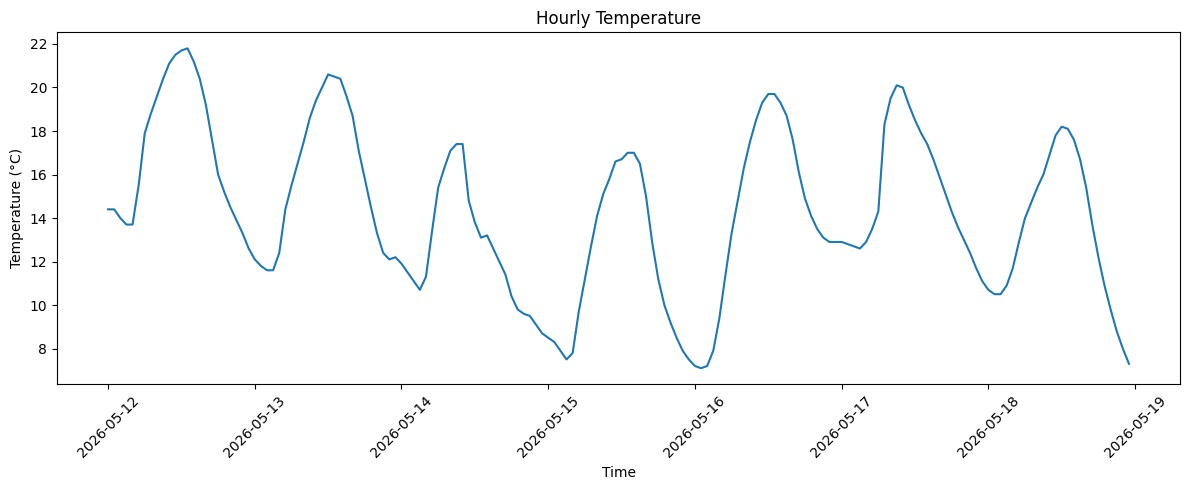

In [32]:
import matplotlib.pyplot as plt

hourly_df = pd.DataFrame({
    "time": pd.to_datetime(data_weather["hourly"]["time"]),
    "temperature_2m": data_weather["hourly"]["temperature_2m"]
})

plt.figure(figsize=(12, 5))
plt.plot(hourly_df["time"], hourly_df["temperature_2m"])
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Hourly Temperature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()